In [28]:
from collections import defaultdict

import pandas as pd
pd.options.display.float_format = '{:>5.2f}'.format
import numpy as np

import matplotlib.pyplot as plt
import json
from pprint import pprint

from scipy.ndimage.filters import gaussian_filter1d

In [44]:
filename = "log/train_GNN_reasoner_q2b/output.log"
metrics = ['mrr', 'hit1', 'hit3', 'hit10']

Conjunction_queries = ['1p', '2p', '3p', '2i', '3i', 'ip', 'pi']
Negation_queries = ['2in', '3in', 'inp', 'pin', 'pni']
Disjunction_queries = ['2u', 'up', '2u-dm', 'up-dm']
queries = Conjunction_queries + Negation_queries + Disjunction_queries

filter_width = 500

In [30]:
def read_log_lines(filename):
    lines = []
    with open(filename, 'rt') as f:
        for line in f.readlines():
            lines.append(line)
    return lines

def filter_lines(lines, key_str):
    rec = []
    for line in lines:
        if not key_str in line:
            continue
        json_content = json.loads(line.split(']')[-1])
        try:
            rec.append(
                json_content
            )
        except:
            print("Error in ", line)
    return rec 

In [31]:
def plot_train_lines(lines):
    rec = filter_lines(lines=lines, key_str="learn")
    if not rec:
        return
    data = defaultdict(list)
    for i, this_record in enumerate(rec):
        for k in this_record:
            data[k].append(this_record[k])
        data['id'].append(i)
    df = pd.DataFrame(data)

    fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(7, 3))

    ax1.set_xlabel('steps')
    ax1.set_ylabel('truth value')

    keys = ['pos_tv', 'neg_tv', 'lifted_tv']
    for label in keys:
        if label in df.columns:
            ax1.plot(df['id'], gaussian_filter1d(df[label], filter_width), label=label)
    # ax1.plot(df['id'], gaussian_filter1d(df['pos_tv'] - df['neg_tv'], filter_width), label='pos - neg', color='purple', alpha=0.5)
    ax1.axhline(y=0.5, color='r', linestyle='-')
    ax1.legend()
    # ax1.set_yscale('log')


    ax2.set_xlabel('steps')
    ax2.set_ylabel('loss')

    keys = ['loss']
    for label in keys:
        if label in df:
            ax2.plot(df['id'], gaussian_filter1d(df[label], filter_width), label=label)
        
    ax2.legend()
    
    keys = ['pos_dist', 'neg_dist']
    for label in keys:
        if label in df:
            ax3.plot(df['id'], gaussian_filter1d(df[label], filter_width), label=label)
        
    ax3.legend()

    # ax2.set_yscale('log')
    # ax2.set_yticks([1e-2, 1e-1, 1])
    fig.tight_layout()  # otherwise the right y-label is slightly clipped
    plt.show()


def plot_evaluation(scope=['train', 'validate', 'test']):
    all_rec = filter_lines(lines=lines, key_str="evaluate")

    
    for k in queries:        
        if not any(k in rec for rec in all_rec): continue
        fig, axes = plt.subplots(ncols=len(scope), figsize=(3 * len(scope) + 1, 3))
        
        if len(scope) == 1:
            axes = [axes]

        for ax, desc in zip(axes, scope):
            rec = filter_lines(lines=lines, key_str=f"evaluate {desc}")
            if not rec: continue
            if k not in rec[0]: continue

            data = defaultdict(list)
            for i, this_record in enumerate(rec):
                for k1 in this_record[k]:
                    data[k1].append(this_record[k][k1])
                data['id'].append(i)

            df = pd.DataFrame(data)

            ax.set_xlabel('epoch')
            ax.set_ylabel('score')
            ax.set_title(f'{desc} scores for query {k}')

            for label in metrics:
                if len(df['id']) == 1:
                    ax.scatter(df['id'], df[label] * 100, label=label)
                else:
                    ax.plot(df['id'], df[label] * 100, label=label)
            ax.legend()
            # ax.set_ylim([0, 1])

        fig.tight_layout()  # otherwise the right y-label is slightly clipped
        plt.show()

In [38]:
def evaluation_to_tables(line, collect_metrics=metrics, verbose=True):
    data = defaultdict(list)
    for m in collect_metrics:
        data['metric'].append(m)
        for k in queries:
            if k in line:
                data[k].append(line[k][m] * 100)
    df = pd.DataFrame(data)
    try:
        df['epfo mean'] = df[Conjunction_queries + Disjunction_queries].mean(axis=1)
    except:
        pass
    try:
        df['Neg mean'] = df[Negation_queries].mean(axis=1)
    except:
        pass    
    return df

def aggregate_evaluations(lines, key_str, collect_metrics=metrics):
    rec_lines = filter_lines(lines, key_str)
    df_list = []
    for e, line in enumerate(rec_lines):
        df = evaluation_to_tables(line, collect_metrics)
        # print(df.to_markdown(floatfmt=".2f"))
        df['epoch'] = e
        df_list.append(df)
    final_df = pd.concat(df_list)
    final_df = final_df.set_index(['epoch', 'metric'])
    print(final_df.to_markdown(floatfmt=".1f"))

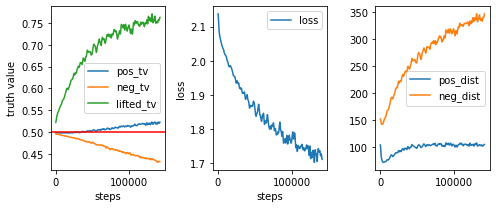

In [45]:
lines = read_log_lines(filename)
plot_train_lines(lines)
# plot_evaluation(scope=['train'])
# aggregate_evaluations(scope=['train', 'valid', 'test'], collect_metrics=['mrr'])

In [46]:
aggregate_evaluations(lines, 'CQD evaluate test', collect_metrics=['mrr'])

|             |   1p |   2p |   3p |   2i |   3i |   ip |   pi |   2u |
|:------------|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|
| (0, 'mrr')  | 46.6 |  3.8 |  1.4 | 16.6 | 18.4 |  1.6 |  2.3 | 25.3 |
| (1, 'mrr')  | 42.2 | 18.7 | 13.6 | 20.6 | 24.2 |  7.5 |  9.9 | 16.4 |
| (2, 'mrr')  | 39.0 | 17.2 | 12.0 | 18.4 | 21.5 |  7.0 |  8.8 | 13.1 |
| (3, 'mrr')  | 35.9 | 15.2 | 10.3 | 15.8 | 18.0 |  6.3 |  7.8 | 11.0 |
| (4, 'mrr')  | 32.3 | 13.3 |  8.4 | 13.3 | 15.1 |  5.3 |  7.1 |  9.3 |
| (5, 'mrr')  | 29.4 | 11.3 |  6.7 | 11.3 | 12.4 |  4.6 |  6.2 |  7.8 |
| (6, 'mrr')  | 26.2 |  9.5 |  5.5 |  9.8 | 10.3 |  3.9 |  5.3 |  6.5 |
| (7, 'mrr')  | 23.6 |  7.6 |  4.6 |  8.3 |  8.9 |  3.4 |  4.8 |  5.7 |
| (8, 'mrr')  | 21.6 |  6.3 |  3.9 |  7.1 |  7.7 |  3.0 |  4.2 |  5.0 |
| (9, 'mrr')  | 20.1 |  6.0 |  3.6 |  6.2 |  6.7 |  2.7 |  3.8 |  4.4 |
| (10, 'mrr') | 18.8 |  4.6 |  2.8 |  5.3 |  5.8 |  2.2 |  3.2 |  3.9 |
| (11, 'mrr') | 17.8 |  4.8 |  2.9 |  4.8 |  5.3 |  2.1 |  3.0 |

In [42]:
aggregate_evaluations(lines, 'NN evaluate valid', collect_metrics=['hit3'])

|              |   1p |   2p |   3p |   2i |   3i |   ip |   pi |   2u |
|:-------------|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|
| (0, 'hit3')  |  2.5 |  0.5 |  0.5 |  1.6 |  2.5 |  1.9 |  2.2 |  0.3 |
| (1, 'hit3')  |  2.5 |  0.6 |  0.5 |  1.6 |  2.5 |  2.1 |  2.2 |  0.6 |
| (2, 'hit3')  | 34.5 | 16.1 | 16.5 | 12.5 | 19.3 |  5.8 |  7.8 | 10.1 |
| (3, 'hit3')  | 35.5 | 17.9 | 15.9 | 13.4 | 18.8 |  5.8 |  9.7 | 10.8 |
| (4, 'hit3')  | 35.2 | 16.4 | 16.1 | 14.5 | 21.9 |  5.7 |  8.9 |  9.0 |
| (5, 'hit3')  | 36.3 | 17.7 | 16.2 | 15.1 | 21.0 |  5.9 | 10.8 |  9.8 |
| (6, 'hit3')  | 34.3 | 16.1 | 15.9 | 12.6 | 16.9 |  5.1 |  7.7 |  8.2 |
| (7, 'hit3')  | 35.2 | 17.7 | 16.0 | 13.2 | 16.7 |  5.2 |  9.2 |  8.9 |
| (8, 'hit3')  | 34.3 | 16.3 | 15.3 | 12.6 | 16.3 |  5.3 |  8.1 |  8.2 |
| (9, 'hit3')  | 35.2 | 17.5 | 15.9 | 12.4 | 16.4 |  5.4 |  9.5 |  9.1 |
| (10, 'hit3') | 34.1 | 15.2 | 15.2 | 12.6 | 16.2 |  4.9 |  7.7 |  7.7 |
| (11, 'hit3') | 35.0 | 15.9 | 15.1 | 12.0 | 16.3 |